In [5]:
import psi4
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import os
import sys
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)
%load_ext autoreload
%autoreload 2
from src.lps_rscf import lps_solver
from src.plot_iter import plot_iter

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload



Final SCF energy: -1.4775 Hartree in 15 iterations


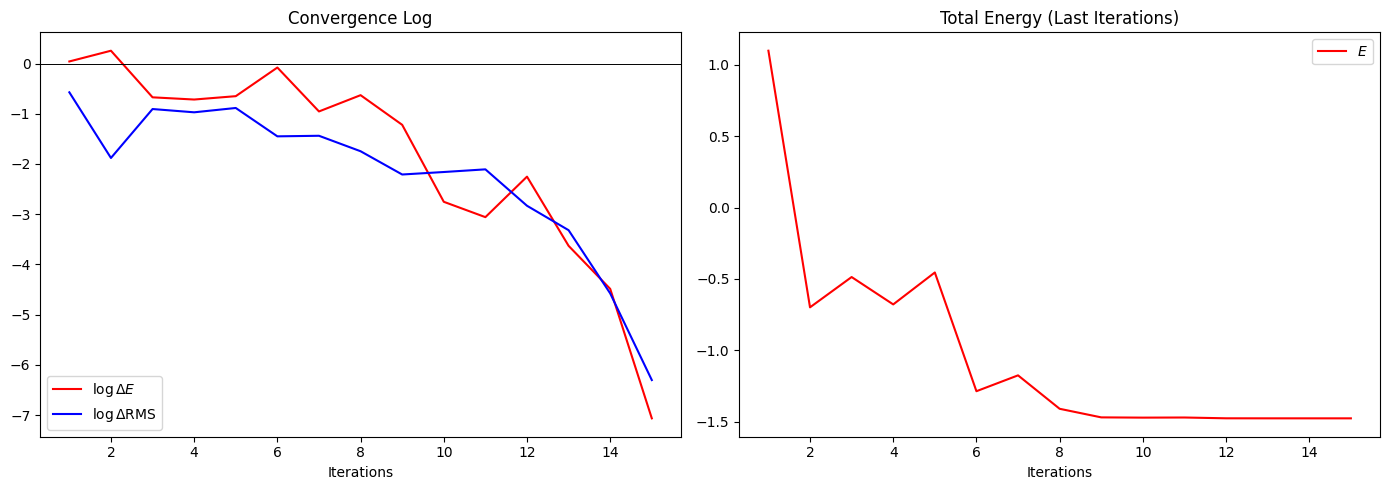

In [4]:
psi4.set_options({'basis': 'UGBS_S', 
                  'DFT_SPHERICAL_POINTS': 6, 
                  'DFT_RADIAL_POINTS': 1000})

atom_label, multip = 'He', 1
mol = psi4.geometry(f"0 {multip}\n {atom_label}\nsymmetry c1")

E, D, mu, iterations, e_list, e_conv, d_conv = lps_solver(
    mol=mol,
    E_conv=1.0e-5,
    D_conv=1.0e-5,
    maxiter=500,
    TP=['LDA_K_TF', 1.0],
    lam=1.0,
    EXC=['LDA_X', 1.0, 'LDA_C_VWN', 0.0],
    FA=[False, 1.0],
    damp=[0.1, 0.0, 0.001],
    Guess=None,
    DIIS=True,
    verbose=False
)
print('\nFinal SCF energy: %.4f Hartree' \
      ' in %.i iterations' % ( E, iterations))

plot_iter(iterations, e_conv, d_conv, e_list, 20)

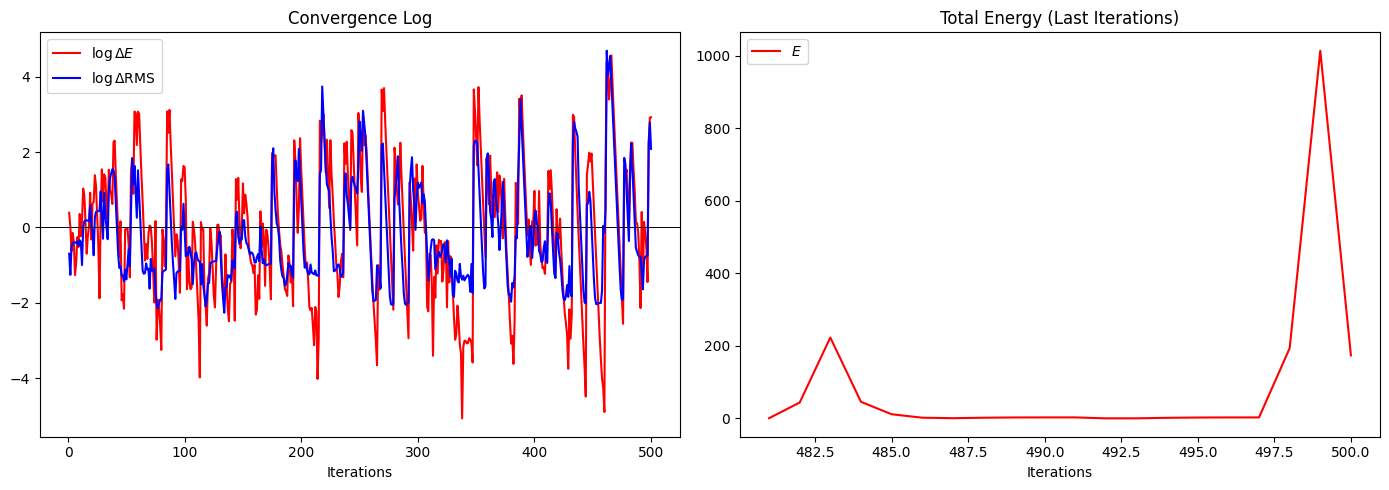

In [58]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

dist = np.linspace(1, iterations, iterations)
ax1.plot(dist, e_conv, color='red', linestyle='-', label='$\\log{\\Delta E}$')
ax1.plot(dist, d_conv, color='blue', linestyle='-', label='$\\log{\\Delta\\text{RMS}}$')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.7)
ax1.legend()
ax1.set_title("Convergence Log")
ax1.set_xlabel("Iterations")

ax2.plot(dist[-20:], e_list[-20:], color='red', linestyle='-', label='$E$')
ax2.legend()
ax2.set_title("Total Energy (Last Iterations)")
ax2.set_xlabel("Iterations")

plt.tight_layout()
plt.show()